In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from scipy import signal
from scipy.stats import describe, pearsonr
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
class PhysiologicalEDA:
    def __init__(self, dataset_dir="dataset"):
        self.dataset_dir = dataset_dir
        self.records_file = os.path.join(dataset_dir, "RECORDS")
        self.record_names = self._load_record_names()
        self.dataset_info = {}
        self.signal_data = {}
        
    def _load_record_names(self):
        """Load record names from RECORDS file"""
        with open(self.records_file, 'r') as f:
            return [line.strip() for line in f.readlines()]
    
    def _format_duration(self, seconds):
        """Format duration in seconds to human readable format"""
        hours = int(seconds // 3600)
        minutes = int((seconds % 3600) // 60)
        secs = int(seconds % 60)
        return f"{hours}h {minutes}m {secs}s"
    
    def analyze_dataset_overview(self):
        """Analyze basic dataset statistics"""
        print("=" * 60)
        print("DATASET OVERVIEW ANALYSIS")
        print("=" * 60)
        
        total_duration = 0
        durations = []
        sampling_freqs = Counter()
        channel_combinations = Counter()
        channel_names = Counter()
        record_info = []

        for record in self.record_names:
            record_path = os.path.join(self.dataset_dir, record)
            try:
                header = wfdb.rdheader(record_path)
                duration = header.sig_len / header.fs
                total_duration += duration
                durations.append(duration)

                sampling_freqs[header.fs] += 1
                combination = tuple(header.sig_name)
                channel_combinations[combination] += 1

                for ch in header.sig_name:
                    channel_names[ch] += 1
                
                record_info.append({
                    'record': record,
                    'duration': duration,
                    'sampling_freq': header.fs,
                    'channels': header.sig_name,
                    'signal_length': header.sig_len
                })

            except Exception as e:
                print(f"Error reading {record_path}: {e}")

        # Store dataset info
        self.dataset_info = {
            'total_records': len(self.record_names),
            'total_duration': total_duration,
            'avg_duration': total_duration / len(self.record_names),
            'min_duration': min(durations),
            'max_duration': max(durations),
            'sampling_freqs': dict(sampling_freqs),
            'channel_names': dict(channel_names),
            'channel_combinations': dict(channel_combinations),
            'record_info': record_info
        }

        # Print results
        print(f"Total Recordings: {len(self.record_names)}")
        print(f"Total Duration: {self._format_duration(total_duration)}")
        print(f"Average Duration: {self._format_duration(total_duration / len(self.record_names))}")
        print(f"Min Duration: {self._format_duration(min(durations))}")
        print(f"Max Duration: {self._format_duration(max(durations))}\n")

        print("Sampling Frequencies:")
        for fs, count in sampling_freqs.items():
            print(f"- {fs} Hz ({count} recordings)")

        print("\nSignal Channels Used:")
        for ch, count in channel_names.items():
            print(f"- {ch} ({count} recordings)")

        print("\nCommon Channel Combinations:")
        for combo, count in channel_combinations.items():
            print(f"- {', '.join(combo)} ({count} recordings)")
        
        return self.dataset_info
    
    def load_sample_signals(self, sample_size=3):
        """Load sample signals for detailed analysis"""
        print(f"\nLoading {sample_size} sample recordings for detailed analysis...")
        
        sample_records = self.record_names[:sample_size]
        
        for record in sample_records:
            try:
                # Load signal data
                record_path = os.path.join(self.dataset_dir, record)
                signals, fields = wfdb.rdsamp(record_path)
                header = wfdb.rdheader(record_path)
                
                # Convert to DataFrame for easier analysis
                df = pd.DataFrame(signals, columns=header.sig_name)
                df['time'] = np.arange(len(df)) / header.fs
                
                self.signal_data[record] = {
                    'data': df,
                    'header': header,
                    'fields': fields
                }
                
                print(f"✓ Loaded {record}: {len(df)} samples, {header.fs} Hz")
                
            except Exception as e:
                print(f"✗ Error loading {record}: {e}")
    
    def plot_signal_overview(self, record_name):
        """Plot overview of all signals in a recording"""
        if record_name not in self.signal_data:
            print(f"Record {record_name} not loaded. Please load it first.")
            return
        
        data = self.signal_data[record_name]['data']
        header = self.signal_data[record_name]['header']
        
        fig, axes = plt.subplots(len(header.sig_name), 1, figsize=(15, 3*len(header.sig_name)))
        if len(header.sig_name) == 1:
            axes = [axes]
        
        for i, channel in enumerate(header.sig_name):
            axes[i].plot(data['time'], data[channel], linewidth=0.5)
            axes[i].set_title(f'{channel} Signal')
            axes[i].set_xlabel('Time (seconds)')
            axes[i].set_ylabel('Amplitude')
            axes[i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.suptitle(f'Signal Overview - {record_name}', y=1.02, fontsize=16)
        plt.show()
    
    def analyze_signal_statistics(self, record_name):
        """Analyze statistical properties of signals"""
        if record_name not in self.signal_data:
            print(f"Record {record_name} not loaded. Please load it first.")
            return
        
        data = self.signal_data[record_name]['data']
        header = self.signal_data[record_name]['header']
        
        print(f"\n{'='*50}")
        print(f"SIGNAL STATISTICS - {record_name}")
        print(f"{'='*50}")
        
        stats_df = pd.DataFrame()
        
        for channel in header.sig_name:
            signal_data = data[channel].values
            stats = describe(signal_data)
            
            stats_df[channel] = {
                'Mean': stats.mean,
                'Std': np.sqrt(stats.variance),
                'Min': stats.minmax[0],
                'Max': stats.minmax[1],
                'Skewness': stats.skewness,
                'Kurtosis': stats.kurtosis,
                'Range': stats.minmax[1] - stats.minmax[0],
                'Variance': stats.variance
            }
        
        print(stats_df.round(4))
        return stats_df
    
    def plot_signal_distributions(self, record_name):
        """Plot distribution of signal values"""
        if record_name not in self.signal_data:
            print(f"Record {record_name} not loaded. Please load it first.")
            return
        
        data = self.signal_data[record_name]['data']
        header = self.signal_data[record_name]['header']
        
        n_channels = len(header.sig_name)
        fig, axes = plt.subplots(2, n_channels, figsize=(4*n_channels, 8))
        
        for i, channel in enumerate(header.sig_name):
            signal_data = data[channel].values
            
            # Histogram
            axes[0, i].hist(signal_data, bins=50, alpha=0.7, edgecolor='black')
            axes[0, i].set_title(f'{channel} - Distribution')
            axes[0, i].set_xlabel('Amplitude')
            axes[0, i].set_ylabel('Frequency')
            
            # Box plot
            axes[1, i].boxplot(signal_data)
            axes[1, i].set_title(f'{channel} - Box Plot')
            axes[1, i].set_ylabel('Amplitude')
        
        plt.tight_layout()
        plt.suptitle(f'Signal Distributions - {record_name}', y=1.02, fontsize=16)
        plt.show()
    
    def analyze_frequency_domain(self, record_name, channels=None):
        """Analyze frequency domain characteristics"""
        if record_name not in self.signal_data:
            print(f"Record {record_name} not loaded. Please load it first.")
            return
        
        data = self.signal_data[record_name]['data']
        header = self.signal_data[record_name]['header']
        
        if channels is None:
            channels = header.sig_name
        
        print(f"\n{'='*50}")
        print(f"FREQUENCY DOMAIN ANALYSIS - {record_name}")
        print(f"{'='*50}")
        
        fig, axes = plt.subplots(len(channels), 2, figsize=(15, 4*len(channels)))
        if len(channels) == 1:
            axes = axes.reshape(1, -1)
        
        freq_analysis = {}
        
        for i, channel in enumerate(channels):
            signal_data = data[channel].values
            fs = header.fs
            
            # Compute FFT
            fft_vals = np.fft.fft(signal_data)
            fft_freq = np.fft.fftfreq(len(signal_data), 1/fs)
            
            # Power spectral density
            freqs, psd = signal.welch(signal_data, fs, nperseg=min(256, len(signal_data)//4))
            
            # Plot FFT
            axes[i, 0].plot(fft_freq[:len(fft_freq)//2], 
                           np.abs(fft_vals[:len(fft_freq)//2]))
            axes[i, 0].set_title(f'{channel} - FFT Magnitude')
            axes[i, 0].set_xlabel('Frequency (Hz)')
            axes[i, 0].set_ylabel('Magnitude')
            axes[i, 0].grid(True, alpha=0.3)
            
            # Plot PSD
            axes[i, 1].semilogy(freqs, psd)
            axes[i, 1].set_title(f'{channel} - Power Spectral Density')
            axes[i, 1].set_xlabel('Frequency (Hz)')
            axes[i, 1].set_ylabel('Power/Frequency (dB/Hz)')
            axes[i, 1].grid(True, alpha=0.3)
            
            # Store frequency analysis results
            freq_analysis[channel] = {
                'dominant_freq': freqs[np.argmax(psd)],
                'max_power': np.max(psd),
                'total_power': np.sum(psd),
                'mean_freq': np.average(freqs, weights=psd)
            }
        
        plt.tight_layout()
        plt.suptitle(f'Frequency Domain Analysis - {record_name}', y=1.02, fontsize=16)
        plt.show()
        
        # Print frequency analysis summary
        print("\nFrequency Analysis Summary:")
        for channel, analysis in freq_analysis.items():
            print(f"\n{channel}:")
            print(f"  Dominant Frequency: {analysis['dominant_freq']:.2f} Hz")
            print(f"  Maximum Power: {analysis['max_power']:.2e}")
            print(f"  Total Power: {analysis['total_power']:.2e}")
            print(f"  Mean Frequency: {analysis['mean_freq']:.2f} Hz")
        
        return freq_analysis
    
    def analyze_correlations(self, record_name):
        """Analyze correlations between different signals"""
        if record_name not in self.signal_data:
            print(f"Record {record_name} not loaded. Please load it first.")
            return
        
        data = self.signal_data[record_name]['data']
        header = self.signal_data[record_name]['header']
        
        # Calculate correlation matrix
        signal_columns = [col for col in data.columns if col != 'time']
        corr_matrix = data[signal_columns].corr()
        
        # Plot correlation heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                   square=True, fmt='.3f')
        plt.title(f'Signal Correlations - {record_name}')
        plt.tight_layout()
        plt.show()
        
        # Print significant correlations
        print(f"\n{'='*50}")
        print(f"CORRELATION ANALYSIS - {record_name}")
        print(f"{'='*50}")
        
        print("\nSignificant Correlations (|r| > 0.3):")
        for i in range(len(signal_columns)):
            for j in range(i+1, len(signal_columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.3:
                    print(f"{signal_columns[i]} ↔ {signal_columns[j]}: {corr_val:.3f}")
        
        return corr_matrix
    
    def analyze_signal_quality(self, record_name):
        """Analyze signal quality indicators"""
        if record_name not in self.signal_data:
            print(f"Record {record_name} not loaded. Please load it first.")
            return
        
        data = self.signal_data[record_name]['data']
        header = self.signal_data[record_name]['header']
        
        print(f"\n{'='*50}")
        print(f"SIGNAL QUALITY ANALYSIS - {record_name}")
        print(f"{'='*50}")
        
        quality_metrics = {}
        
        for channel in header.sig_name:
            signal_data = data[channel].values
            
            # Calculate quality metrics
            snr = np.mean(signal_data**2) / np.var(signal_data) if np.var(signal_data) > 0 else 0
            zero_crossings = np.sum(np.diff(np.sign(signal_data)) != 0)
            peak_to_peak = np.max(signal_data) - np.min(signal_data)
            rms = np.sqrt(np.mean(signal_data**2))
            
            quality_metrics[channel] = {
                'SNR': snr,
                'Zero_Crossings': zero_crossings,
                'Peak_to_Peak': peak_to_peak,
                'RMS': rms,
                'Dynamic_Range': 20 * np.log10(peak_to_peak / (np.std(signal_data) + 1e-10))
            }
        
        # Create quality metrics DataFrame
        quality_df = pd.DataFrame(quality_metrics).T
        print(quality_df.round(4))
        
        return quality_df
    
    def plot_signal_segments(self, record_name, segment_length=30):
        """Plot different segments of the signal to show temporal variations"""
        if record_name not in self.signal_data:
            print(f"Record {record_name} not loaded. Please load it first.")
            return
        
        data = self.signal_data[record_name]['data']
        header = self.signal_data[record_name]['header']
        fs = header.fs
        
        # Calculate number of segments
        samples_per_segment = int(segment_length * fs)
        n_segments = min(3, len(data) // samples_per_segment)
        
        fig, axes = plt.subplots(n_segments, len(header.sig_name), 
                                figsize=(4*len(header.sig_name), 4*n_segments))
        
        if n_segments == 1:
            axes = axes.reshape(1, -1)
        
        for seg in range(n_segments):
            start_idx = seg * samples_per_segment
            end_idx = start_idx + samples_per_segment
            
            for ch_idx, channel in enumerate(header.sig_name):
                segment_data = data[channel].iloc[start_idx:end_idx]
                time_segment = data['time'].iloc[start_idx:end_idx]
                
                axes[seg, ch_idx].plot(time_segment, segment_data, linewidth=0.8)
                axes[seg, ch_idx].set_title(f'{channel} - Segment {seg+1}')
                axes[seg, ch_idx].set_xlabel('Time (s)')
                axes[seg, ch_idx].set_ylabel('Amplitude')
                axes[seg, ch_idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.suptitle(f'Signal Segments - {record_name} ({segment_length}s each)', 
                    y=1.02, fontsize=16)
        plt.show()
    
    def generate_comprehensive_report(self,sample_size=2):
        """Generate a comprehensive EDA report"""
        print("=" * 80)
        print("COMPREHENSIVE EXPLORATORY DATA ANALYSIS REPORT")
        print("=" * 80)
        
        # 1. Dataset Overview
        self.analyze_dataset_overview()
        
        # 2. Load sample signals
        self.load_sample_signals(sample_size)
        
        if not self.signal_data:
            print("No signals loaded. Cannot proceed with detailed analysis.")
            return
        
        # 3. Detailed analysis for each loaded record
        for record_name in self.signal_data.keys():
            print(f"\n{'='*80}")
            print(f"DETAILED ANALYSIS FOR RECORD: {record_name}")
            print(f"{'='*80}")
            
            # Signal overview plots
            self.plot_signal_overview(record_name)
            
            # Statistical analysis
            stats_df = self.analyze_signal_statistics(record_name)
            
            # Distribution analysis
            self.plot_signal_distributions(record_name)
            
            # Frequency domain analysis
            freq_analysis = self.analyze_frequency_domain(record_name)
            
            # Correlation analysis
            corr_matrix = self.analyze_correlations(record_name)
            
            # Signal quality analysis
            quality_df = self.analyze_signal_quality(record_name)
            
            # Temporal analysis
            self.plot_signal_segments(record_name)
        
        print(f"\n{'='*80}")
        print("EDA ANALYSIS COMPLETE")
        print(f"{'='*80}")
        print("\nKey Insights:")
        print("1. Dataset contains physiological signals (ECG, EMG, GSR, HR, RESP)")
        print("2. Multiple sampling frequencies present (15, 15.5, 31 Hz)")
        print("3. Variable channel combinations across recordings")
        print("4. Long-duration recordings (25+ minutes each)")
        print("5. Mixed signal types requiring different analysis approaches")

COMPREHENSIVE EXPLORATORY DATA ANALYSIS REPORT
DATASET OVERVIEW ANALYSIS
Total Recordings: 18
Total Duration: 22h 14m 7s
Average Duration: 1h 14m 7s
Min Duration: 0h 25m 26s
Max Duration: 1h 32m 42s

Sampling Frequencies:
- 15.5 Hz (16 recordings)
- 31 Hz (1 recordings)
- 15 Hz (1 recordings)

Signal Channels Used:
- ECG (18 recordings)
- EMG (15 recordings)
- foot GSR (18 recordings)
- hand GSR (15 recordings)
- HR (16 recordings)
- RESP (18 recordings)
- marker (16 recordings)
- hand GSr (1 recordings)

Common Channel Combinations:
- ECG, EMG, foot GSR, hand GSR, HR, RESP (1 recordings)
- ECG, foot GSR, HR, marker, RESP (1 recordings)
- ECG, foot GSR, hand GSR, RESP (1 recordings)
- ECG, foot GSR, hand GSR, HR, marker, RESP (1 recordings)
- ECG, EMG, foot GSR, hand GSR, HR, marker, RESP (11 recordings)
- ECG, EMG, foot GSR, hand GSr, HR, marker, RESP (1 recordings)
- ECG, EMG, foot GSR, HR, marker, RESP (1 recordings)
- ECG, EMG, foot GSR, hand GSR, marker, RESP (1 recordings)

Loadi

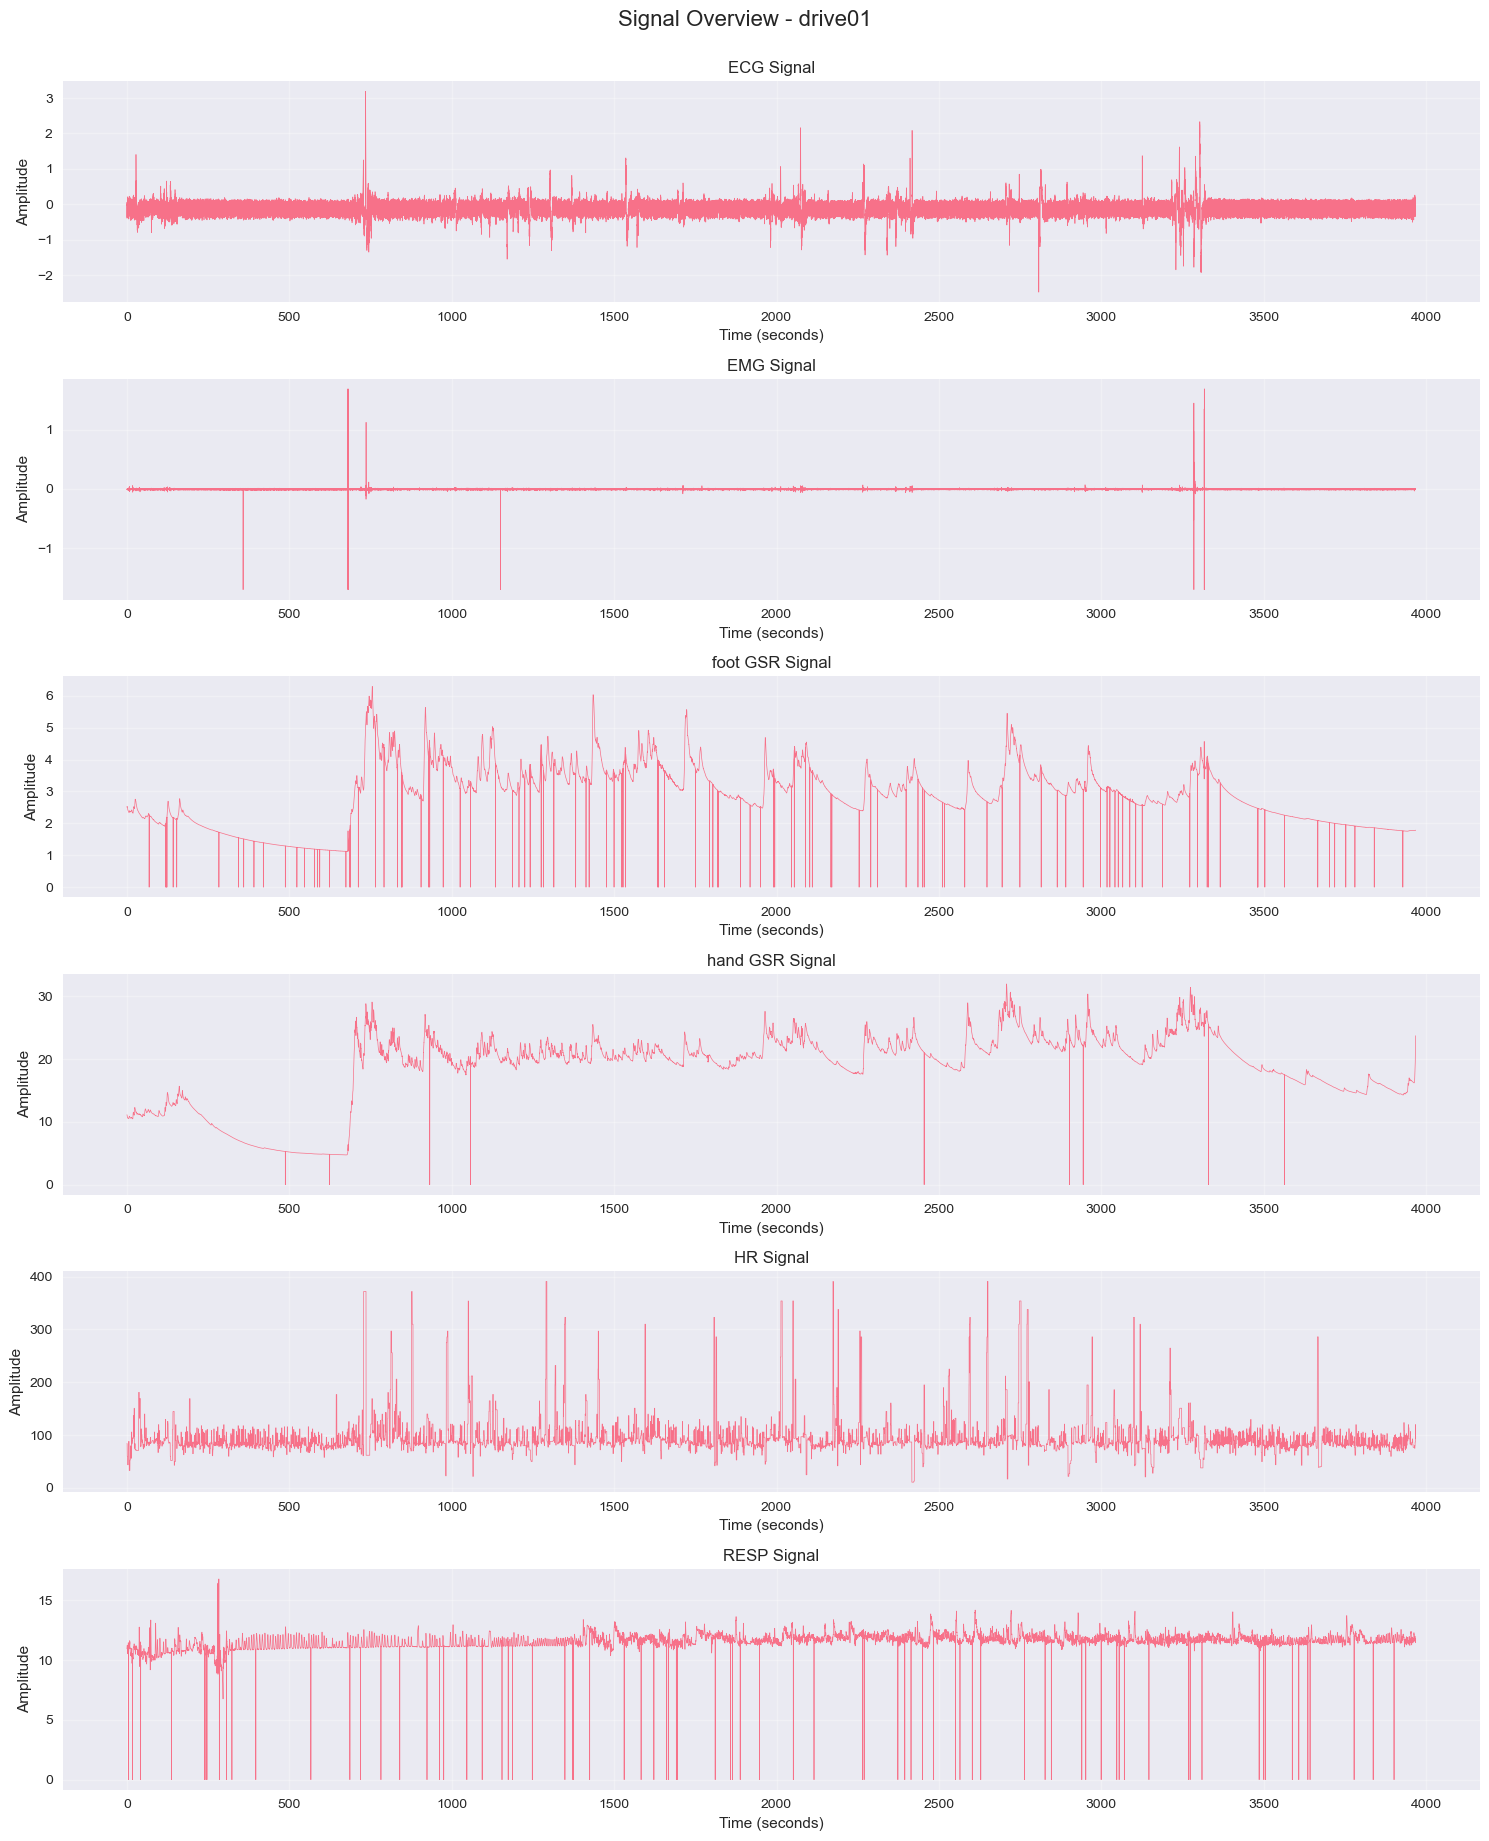


SIGNAL STATISTICS - drive01
              ECG        EMG  foot GSR  hand GSR         HR      RESP
Mean       0.0040    -0.0055    2.8902   18.7057    95.1444   11.5787
Std        0.1997     0.0411    0.9144    5.6960    40.9444    0.7915
Min       -2.4830    -1.7000    0.0000    0.0000    11.0000    0.0000
Max        3.1880     1.6901    6.2920   32.0000   391.0000   16.7940
Skewness   0.3301   -20.6623    0.1129   -1.0362     4.2047   -7.7502
Kurtosis  26.2941  1489.6044    0.0610    0.4937    21.8975  113.7534
Range      5.6710     3.3901    6.2920   32.0000   380.0000   16.7940
Variance   0.0399     0.0017    0.8361   32.4442  1676.4461    0.6264


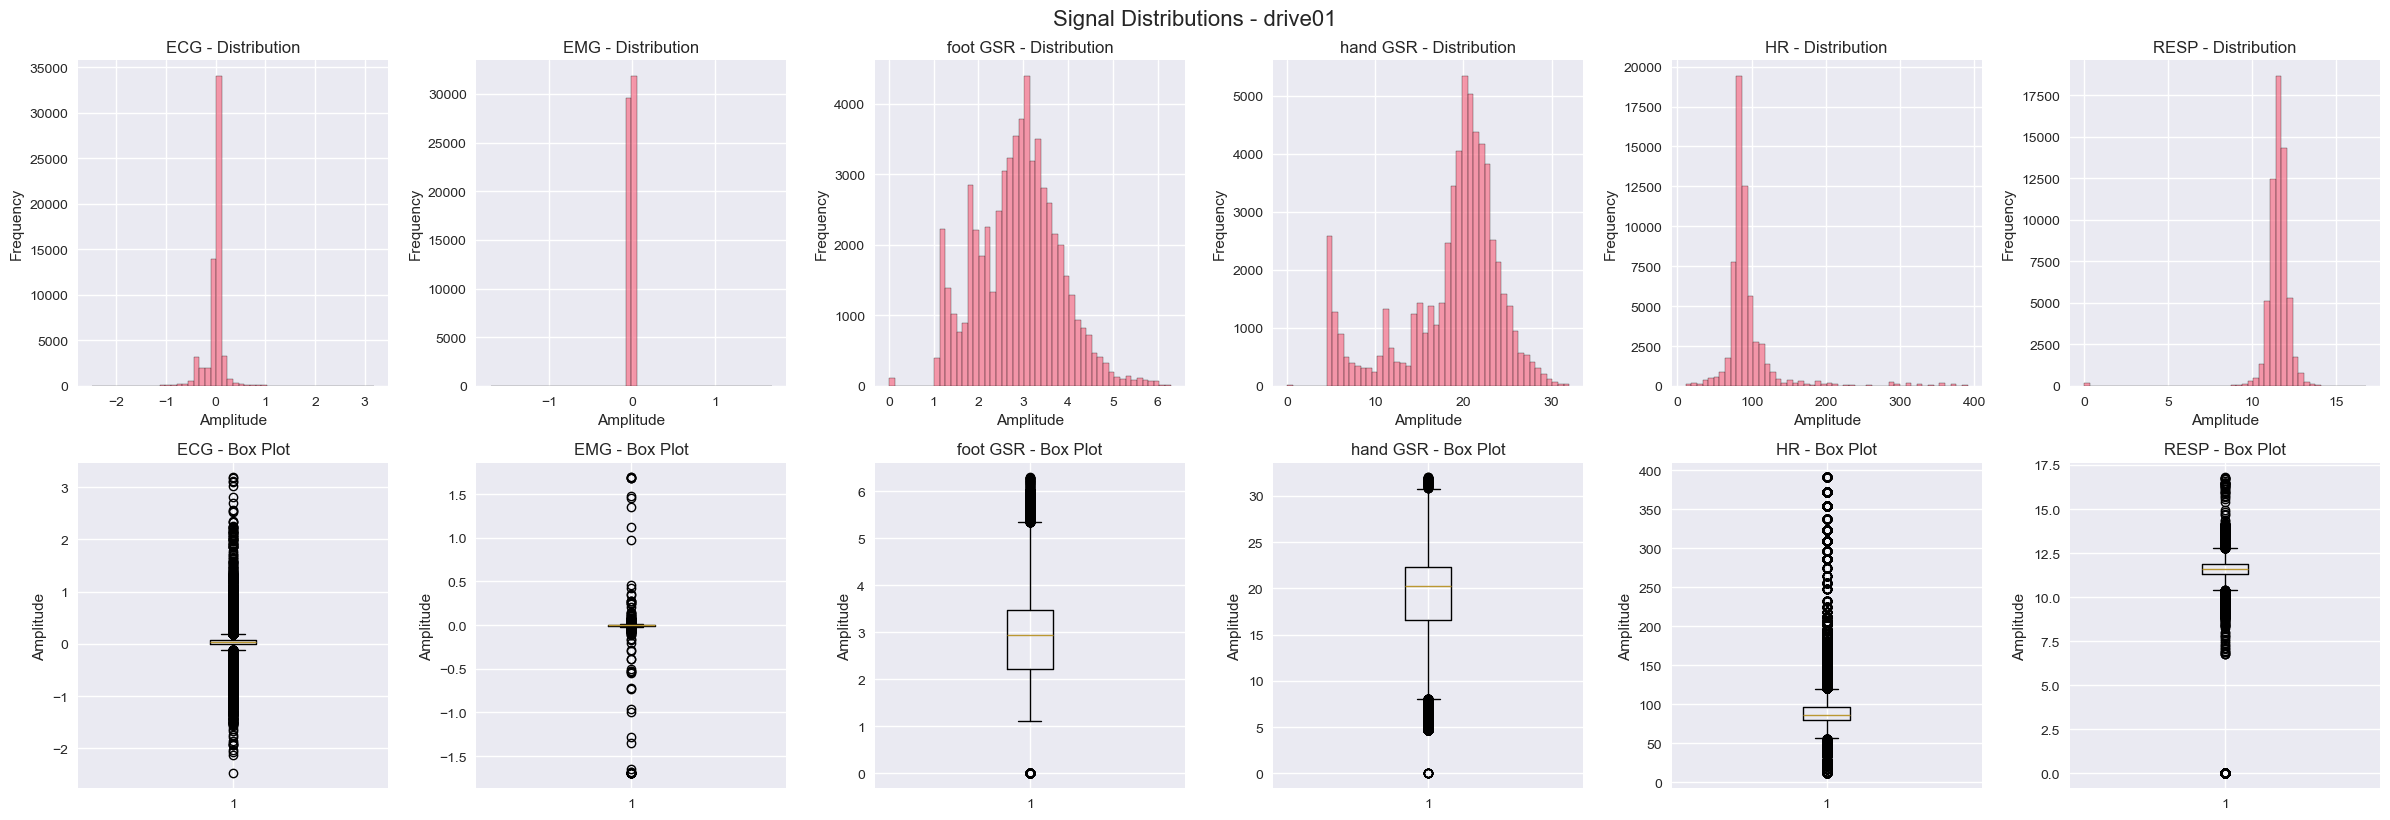


FREQUENCY DOMAIN ANALYSIS - drive01


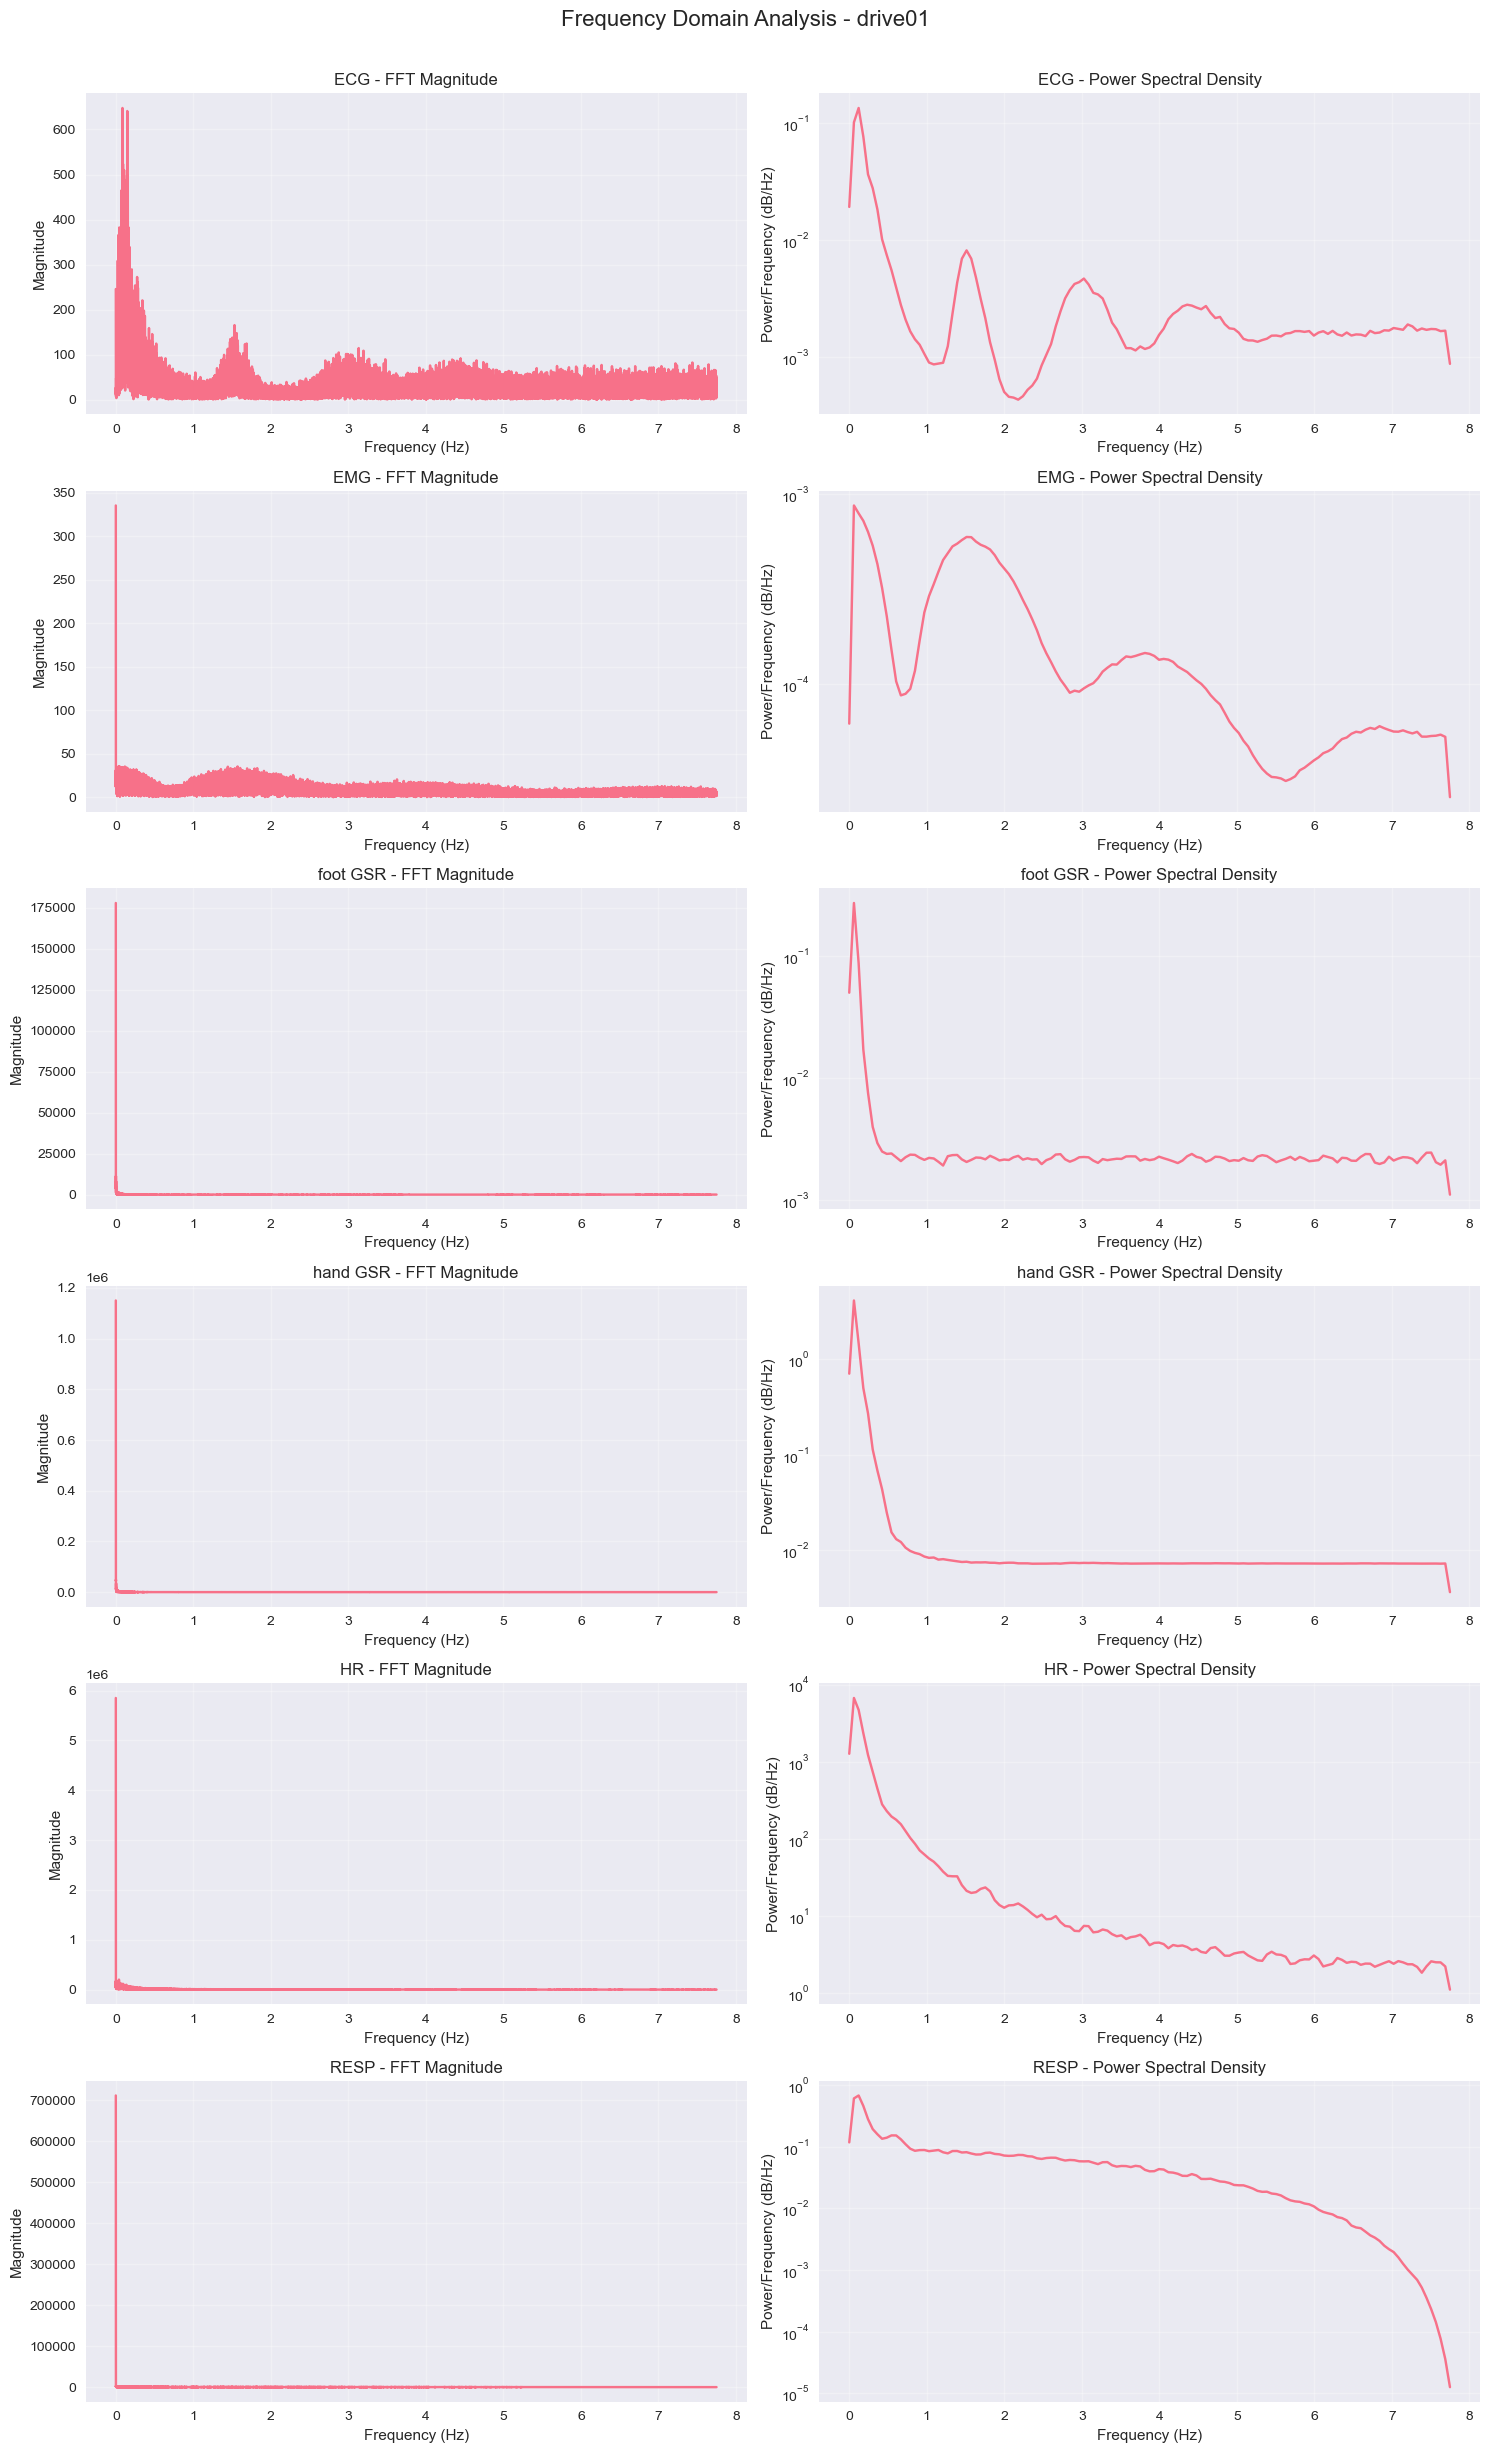


Frequency Analysis Summary:

ECG:
  Dominant Frequency: 0.12 Hz
  Maximum Power: 1.36e-01
  Total Power: 6.74e-01
  Mean Frequency: 1.46 Hz

EMG:
  Dominant Frequency: 0.06 Hz
  Maximum Power: 8.71e-04
  Total Power: 2.29e-02
  Mean Frequency: 2.21 Hz

foot GSR:
  Dominant Frequency: 0.06 Hz
  Maximum Power: 2.70e-01
  Total Power: 7.05e-01
  Mean Frequency: 1.58 Hz

hand GSR:
  Dominant Frequency: 0.06 Hz
  Maximum Power: 4.15e+00
  Total Power: 8.26e+00
  Mean Frequency: 0.52 Hz

HR:
  Dominant Frequency: 0.06 Hz
  Maximum Power: 6.69e+03
  Total Power: 1.98e+04
  Mean Frequency: 0.27 Hz

RESP:
  Dominant Frequency: 0.12 Hz
  Maximum Power: 6.75e-01
  Total Power: 7.81e+00
  Mean Frequency: 1.69 Hz


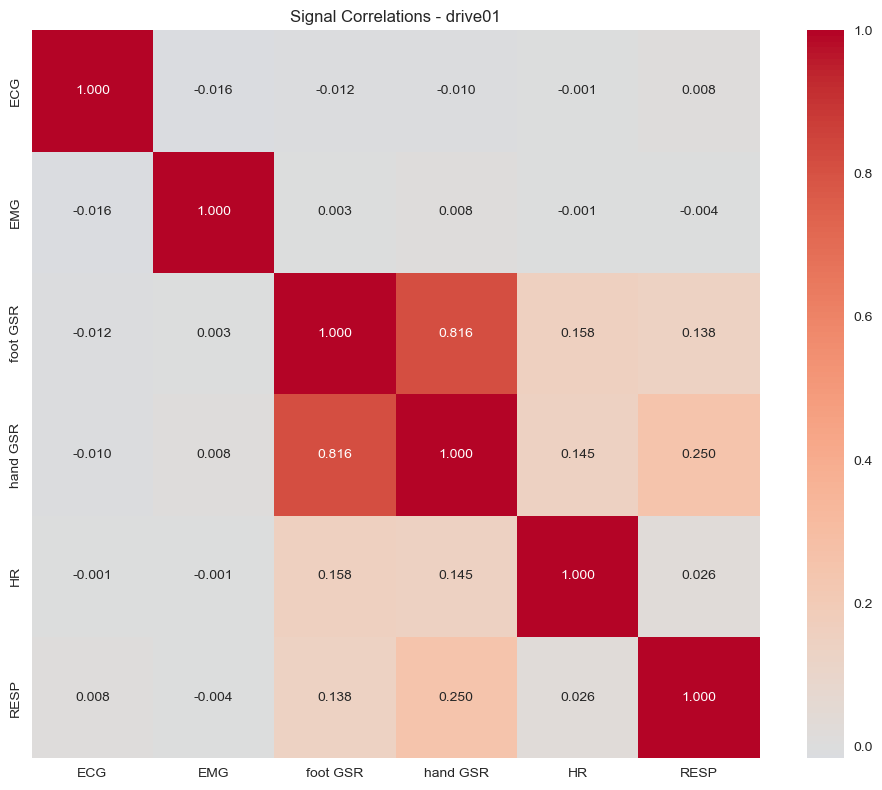


CORRELATION ANALYSIS - drive01

Significant Correlations (|r| > 0.3):
foot GSR ↔ hand GSR: 0.816

SIGNAL QUALITY ANALYSIS - drive01
               SNR  Zero_Crossings  Peak_to_Peak       RMS  Dynamic_Range
ECG         1.0004         13249.0        5.6710    0.1997        29.0677
EMG         1.0176         19149.0        3.3901    0.0415        38.3291
foot GSR   10.9910           224.0        6.2920    3.0314        16.7532
hand GSR   11.7850            18.0       32.0000   19.5537        14.9917
HR          6.3999             0.0      380.0000  103.5803        19.3518
RESP      215.0162           154.0       16.7940   11.6057        26.5344


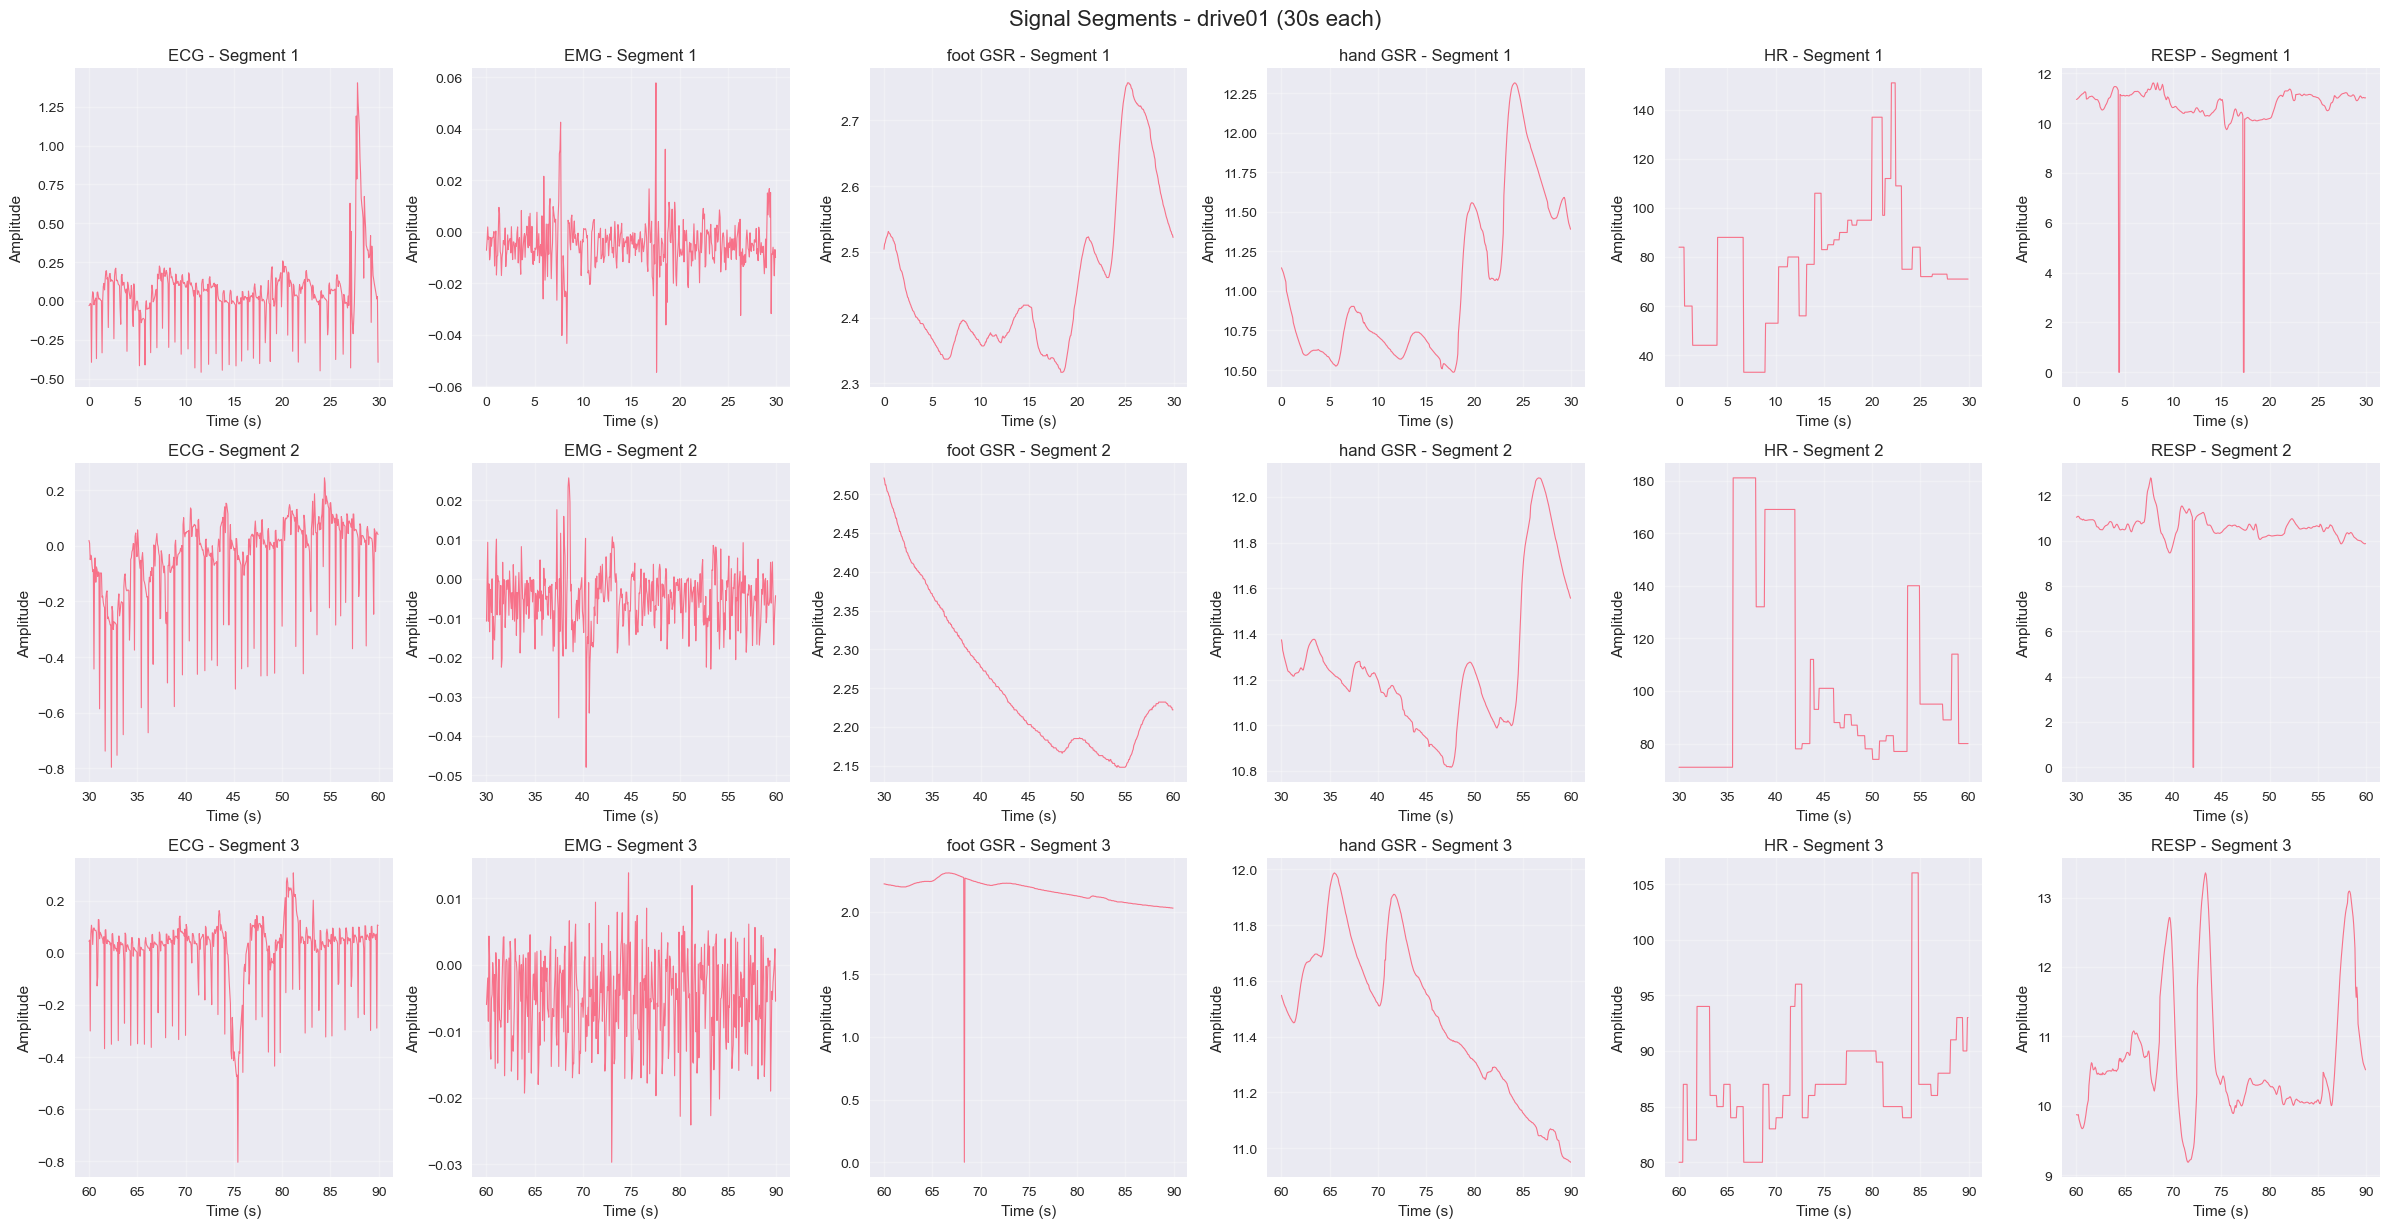


EDA ANALYSIS COMPLETE

Key Insights:
1. Dataset contains physiological signals (ECG, EMG, GSR, HR, RESP)
2. Multiple sampling frequencies present (15, 15.5, 31 Hz)
3. Variable channel combinations across recordings
4. Long-duration recordings (25+ minutes each)
5. Mixed signal types requiring different analysis approaches


In [9]:
eda = PhysiologicalEDA()
eda.generate_comprehensive_report(1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class FeatureEDA:
    def __init__(self, features_dir="features", annotations_dir="annotations"):
        self.features_dir = Path(features_dir)
        self.annotations_dir = Path(annotations_dir)
        self.combined_data = None
        self.feature_columns = None
        
    def load_all_features(self):
        """Load all feature files and combine them"""
        print("Loading all feature files...")
        
        all_data = []
        feature_files = list(self.features_dir.glob("*.csv"))
        
        for file_path in feature_files:
            try:
                df = pd.read_csv(file_path)
                # Extract drive number from filename
                drive_num = file_path.stem.replace('_features', '')
                df['drive'] = drive_num
                all_data.append(df)
                print(f"Loaded {file_path.name} with {len(df)} rows")
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
        
        if all_data:
            self.combined_data = pd.concat(all_data, ignore_index=True)
            self.feature_columns = [col for col in self.combined_data.columns 
                                  if col not in ['drive', 'label']]
            print(f"\nCombined dataset shape: {self.combined_data.shape}")
            print(f"Number of features: {len(self.feature_columns)}")
            print(f"Number of drives: {self.combined_data['drive'].nunique()}")
        else:
            raise ValueError("No feature files found!")
    
    def basic_info(self):
        """Display basic information about the dataset"""
        print("\n" + "="*50)
        print("BASIC DATASET INFORMATION")
        print("="*50)
        
        print(f"Dataset shape: {self.combined_data.shape}")
        print(f"Features: {len(self.feature_columns)}")
        print(f"Drives: {self.combined_data['drive'].nunique()}")
        print(f"Label distribution:")
        print(self.combined_data['label'].value_counts())
        
        print(f"\nLabel distribution by drive:")
        label_by_drive = self.combined_data.groupby(['drive', 'label']).size().unstack(fill_value=0)
        print(label_by_drive)
        
        print(f"\nMissing values:")
        missing_data = self.combined_data.isnull().sum()
        if missing_data.sum() > 0:
            print(missing_data[missing_data > 0])
        else:
            print("No missing values found!")
    
    def feature_statistics(self):
        """Analyze feature statistics"""
        print("\n" + "="*50)
        print("FEATURE STATISTICS")
        print("="*50)
        
        # Basic statistics
        stats = self.combined_data[self.feature_columns].describe()
        print("Feature Statistics:")
        print(stats)
        
        # Check for infinite values
        inf_counts = np.isinf(self.combined_data[self.feature_columns]).sum()
        if inf_counts.sum() > 0:
            print(f"\nInfinite values found:")
            print(inf_counts[inf_counts > 0])
        
        # Check for zero variance features
        zero_var_features = []
        for col in self.feature_columns:
            if self.combined_data[col].var() == 0:
                zero_var_features.append(col)
        
        if zero_var_features:
            print(f"\nZero variance features: {zero_var_features}")
        else:
            print(f"\nNo zero variance features found")
    
    def correlation_analysis(self):
        """Analyze feature correlations"""
        print("\n" + "="*50)
        print("CORRELATION ANALYSIS")
        print("="*50)
        
        # Calculate correlation matrix
        corr_matrix = self.combined_data[self.feature_columns].corr()
        
        # Find highly correlated features
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.8:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
        
        print(f"Highly correlated feature pairs (|correlation| > 0.8):")
        for pair in high_corr_pairs:
            print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")
        
        # Plot correlation heatmap
        plt.figure(figsize=(20, 16))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                   square=True, linewidths=0.5, cbar_kws={"shrink": .8})
        plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
        plt.tight_layout()
        plt.savefig('eda/correlation_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return corr_matrix
    
    def feature_importance_analysis(self):
        """Analyze feature importance using multiple methods"""
        print("\n" + "="*50)
        print("FEATURE IMPORTANCE ANALYSIS")
        print("="*50)
        
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.preprocessing import LabelEncoder
        from sklearn.feature_selection import mutual_info_classif, f_classif
        
        # Prepare data
        X = self.combined_data[self.feature_columns]
        y = self.combined_data['label']
        
        # Encode labels
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        
        # 1. Random Forest Feature Importance
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X, y_encoded)
        rf_importance = pd.DataFrame({
            'feature': self.feature_columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("Random Forest Feature Importance (Top 10):")
        print(rf_importance.head(10))
        
        # 2. Mutual Information
        mi_scores = mutual_info_classif(X, y_encoded, random_state=42)
        mi_importance = pd.DataFrame({
            'feature': self.feature_columns,
            'mutual_info': mi_scores
        }).sort_values('mutual_info', ascending=False)
        
        print("\nMutual Information Scores (Top 10):")
        print(mi_importance.head(10))
        
        # 3. ANOVA F-statistic
        f_scores, p_values = f_classif(X, y_encoded)
        f_importance = pd.DataFrame({
            'feature': self.feature_columns,
            'f_score': f_scores,
            'p_value': p_values
        }).sort_values('f_score', ascending=False)
        
        print("\nANOVA F-statistic (Top 10):")
        print(f_importance.head(10))
        
        # Plot feature importance
        fig, axes = plt.subplots(1, 3, figsize=(20, 8))
        
        # RF Importance
        top_rf = rf_importance.head(15)
        axes[0].barh(range(len(top_rf)), top_rf['importance'])
        axes[0].set_yticks(range(len(top_rf)))
        axes[0].set_yticklabels(top_rf['feature'])
        axes[0].set_title('Random Forest Feature Importance')
        axes[0].set_xlabel('Importance')
        
        # Mutual Information
        top_mi = mi_importance.head(15)
        axes[1].barh(range(len(top_mi)), top_mi['mutual_info'])
        axes[1].set_yticks(range(len(top_mi)))
        axes[1].set_yticklabels(top_mi['feature'])
        axes[1].set_title('Mutual Information Scores')
        axes[1].set_xlabel('Mutual Information')
        
        # F-statistic
        top_f = f_importance.head(15)
        axes[2].barh(range(len(top_f)), top_f['f_score'])
        axes[2].set_yticks(range(len(top_f)))
        axes[2].set_yticklabels(top_f['feature'])
        axes[2].set_title('ANOVA F-statistic')
        axes[2].set_xlabel('F-score')
        
        plt.tight_layout()
        plt.savefig('eda/feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return rf_importance, mi_importance, f_importance
    
    def label_analysis(self):
        """Analyze the relationship between features and labels"""
        print("\n" + "="*50)
        print("LABEL ANALYSIS")
        print("="*50)
        
        # Feature distributions by label
        fig, axes = plt.subplots(4, 4, figsize=(20, 16))
        axes = axes.ravel()
        
        for i, feature in enumerate(self.feature_columns[:16]):  # Plot first 16 features
            for label in self.combined_data['label'].unique():
                data = self.combined_data[self.combined_data['label'] == label][feature]
                axes[i].hist(data, alpha=0.7, label=label, bins=20)
            
            axes[i].set_title(f'{feature} Distribution by Label')
            axes[i].legend()
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Frequency')
        
        # Hide empty subplots
        for i in range(16, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('eda/feature_distributions_by_label.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Box plots for top features
        top_features = ['HR_mean', 'SDNN', 'RMSSD', 'pNN50', 'LF_HF', 'EMG_mean', 'GSR_foot_mean']
        
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.ravel()
        
        for i, feature in enumerate(top_features):
            if feature in self.feature_columns:
                sns.boxplot(data=self.combined_data, x='label', y=feature, ax=axes[i])
                axes[i].set_title(f'{feature} by Label')
                axes[i].tick_params(axis='x', rotation=45)
        
        # Hide empty subplots
        for i in range(len(top_features), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('eda/boxplots_top_features.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def drive_analysis(self):
        """Analyze features across different drives"""
        print("\n" + "="*50)
        print("DRIVE ANALYSIS")
        print("="*50)
        
        # Average features by drive
        drive_means = self.combined_data.groupby('drive')[self.feature_columns].mean()
        
        print("Average feature values by drive:")
        print(drive_means.round(3))
        
        # Plot heatmap of features across drives
        plt.figure(figsize=(20, 12))
        sns.heatmap(drive_means.T, annot=True, cmap='viridis', fmt='.2f')
        plt.title('Feature Values Across Drives', fontsize=16, pad=20)
        plt.xlabel('Drive')
        plt.ylabel('Features')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('eda/features_across_drives.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Label distribution by drive
        plt.figure(figsize=(12, 6))
        label_drive_counts = self.combined_data.groupby(['drive', 'label']).size().unstack(fill_value=0)
        label_drive_counts.plot(kind='bar', stacked=True)
        plt.title('Label Distribution by Drive')
        plt.xlabel('Drive')
        plt.ylabel('Count')
        plt.legend(title='Label')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('eda/label_distribution_by_drive.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def outlier_analysis(self):
        """Analyze outliers in the features"""
        print("\n" + "="*50)
        print("OUTLIER ANALYSIS")
        print("="*50)
        
        # Calculate outliers using IQR method
        outlier_counts = {}
        for feature in self.feature_columns:
            Q1 = self.combined_data[feature].quantile(0.25)
            Q3 = self.combined_data[feature].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = self.combined_data[
                (self.combined_data[feature] < lower_bound) | 
                (self.combined_data[feature] > upper_bound)
            ]
            outlier_counts[feature] = len(outliers)
        
        outlier_df = pd.DataFrame(list(outlier_counts.items()), 
                                columns=['Feature', 'Outlier_Count'])
        outlier_df['Outlier_Percentage'] = (outlier_df['Outlier_Count'] / len(self.combined_data)) * 100
        outlier_df = outlier_df.sort_values('Outlier_Percentage', ascending=False)
        
        print("Features with highest outlier percentages:")
        print(outlier_df.head(10))
        
        # Plot outlier percentages
        plt.figure(figsize=(15, 8))
        top_outliers = outlier_df.head(15)
        plt.bar(range(len(top_outliers)), top_outliers['Outlier_Percentage'])
        plt.xticks(range(len(top_outliers)), top_outliers['Feature'], rotation=45, ha='right')
        plt.title('Outlier Percentage by Feature')
        plt.xlabel('Features')
        plt.ylabel('Outlier Percentage (%)')
        plt.tight_layout()
        plt.savefig('eda/outlier_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def summary_report(self):
        """Generate a summary report"""
        print("\n" + "="*50)
        print("SUMMARY REPORT")
        print("="*50)
        
        # Get top features from different methods
        rf_importance, mi_importance, f_importance = self.feature_importance_analysis()
        
        print("TOP FEATURES BY IMPORTANCE:")
        print("Random Forest (Top 5):", list(rf_importance.head(5)['feature']))
        print("Mutual Information (Top 5):", list(mi_importance.head(5)['feature']))
        print("ANOVA F-statistic (Top 5):", list(f_importance.head(5)['feature']))
        
        # Common top features
        rf_top = set(rf_importance.head(10)['feature'])
        mi_top = set(mi_importance.head(10)['feature'])
        f_top = set(f_importance.head(10)['feature'])
        
        common_features = rf_top.intersection(mi_top).intersection(f_top)
        print(f"\nFeatures consistently ranked high across all methods: {list(common_features)}")
        
        # Data quality summary
        print(f"\nDATA QUALITY SUMMARY:")
        print(f"Total samples: {len(self.combined_data)}")
        print(f"Total features: {len(self.feature_columns)}")
        print(f"Number of drives: {self.combined_data['drive'].nunique()}")
        print(f"Label balance:")
        print(self.combined_data['label'].value_counts(normalize=True))
        
        # Save summary to file
        with open('eda/eda_summary.txt', 'w') as f:
            f.write("FEATURE EDA SUMMARY REPORT\n")
            f.write("="*50 + "\n\n")
            f.write(f"Dataset shape: {self.combined_data.shape}\n")
            f.write(f"Features: {len(self.feature_columns)}\n")
            f.write(f"Drives: {self.combined_data['drive'].nunique()}\n\n")
            
            f.write("TOP FEATURES BY IMPORTANCE:\n")
            f.write("Random Forest (Top 10):\n")
            for _, row in rf_importance.head(10).iterrows():
                f.write(f"  {row['feature']}: {row['importance']:.4f}\n")
            
            f.write("\nMutual Information (Top 10):\n")
            for _, row in mi_importance.head(10).iterrows():
                f.write(f"  {row['feature']}: {row['mutual_info']:.4f}\n")
            
            f.write("\nANOVA F-statistic (Top 10):\n")
            for _, row in f_importance.head(10).iterrows():
                f.write(f"  {row['feature']}: {row['f_score']:.4f} (p={row['p_value']:.4f})\n")
        
        print(f"\nDetailed summary saved to 'eda/eda_summary.txt'")
    
    def run_complete_eda(self):
        """Run the complete EDA pipeline"""
        print("Starting Comprehensive Feature EDA...")
        
        # Create output directory
        Path('eda').mkdir(exist_ok=True)
        
        # Load data
        self.load_all_features()
        
        # Run all analyses
        self.basic_info()
        self.feature_statistics()
        self.correlation_analysis()
        self.feature_importance_analysis()
        self.label_analysis()
        self.drive_analysis()
        self.outlier_analysis()
        self.summary_report()
        
        print("\n" + "="*50)
        print("EDA COMPLETED SUCCESSFULLY!")
        print("="*50)
        print("Generated files:")
        print("- eda/correlation_heatmap.png")
        print("- eda/feature_importance.png")
        print("- eda/feature_distributions_by_label.png")
        print("- eda/boxplots_top_features.png")
        print("- eda/features_across_drives.png")
        print("- eda/label_distribution_by_drive.png")
        print("- eda/outlier_analysis.png")
        print("- eda/eda_summary.txt")

if __name__ == "__main__":
    # Run the complete EDA
    eda = FeatureEDA()
    eda.run_complete_eda()


Starting Comprehensive Feature EDA...
Loading all feature files...


ValueError: No feature files found!